# Step 1: Exploratory Data Analysis

**Goal:** Understand the MIT-BIH dataset structure, quantify class imbalance,
and visualize representative ECG waveforms per class.

**Outputs:**
- `results/plots/class_distribution.png`
- `results/plots/class_waveforms.png`
- Per-class statistics table (motivation for preprocessing decisions)
- `data/processed/reference_waveforms.npz` (canonical waveforms for Streamlit gallery)

In [1]:
import sys, os
from pathlib import Path
_r = Path.cwd()
while not (_r / 'src').is_dir():
    _r = _r.parent
os.chdir(_r)
if str(_r) not in sys.path:
    sys.path.insert(0, str(_r))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_mitbih
from src.eda.class_distribution import plot_class_distribution, print_class_statistics
from src.eda.waveform_visualizer import plot_class_waveforms, get_representative_sample
from src.eda.statistics import compute_class_statistics

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load raw data
X_train, y_train, X_test, y_test = load_mitbih()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Signal length: {X_train.shape[1]} values per beat')

Train: (87554, 187), Test: (21892, 187)
Signal length: 187 values per beat



Class                           Count   Percentage
--------------------------------------------------
Normal (N)                     72,471        82.8%
Supraventricular (S)            2,223         2.5%
Ventricular (V)                 5,788         6.6%
Fusion (F)                        641         0.7%
Unknown (Q)                     6,431         7.3%
--------------------------------------------------
Total                          87,554       100.0%



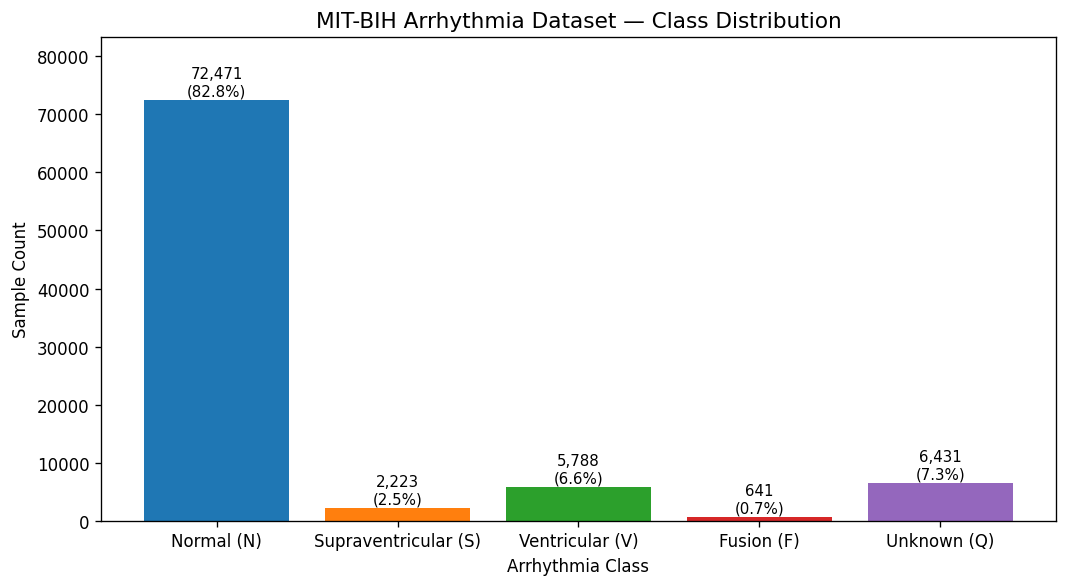

In [3]:
# Class distribution — confirms severe imbalance motivating Focal Loss + SMOTE
print_class_statistics(y_train)
plot_class_distribution(y_train, save_path='results/plots/class_distribution.png')

In [4]:
# Per-class signal statistics — motivates Z-score normalization and IQR outlier removal
stats_df = compute_class_statistics(X_train, y_train)
display(stats_df)

,count,mean_amplitude,variance,min,max,iqr,beat_length_mean,beat_length_std
class,,,,,,,,
Normal (N),72471,0.161896,0.047334,0.0,1.0,0.266430,108.776007,27.119241
Supraventricular (S),2223,0.194778,0.046066,0.0,1.0,0.333333,112.342780,39.121831
Ventricular (V),5788,0.243849,0.068824,0.0,1.0,0.397315,116.019350,34.764207
Fusion (F),641,0.107253,0.037268,0.0,1.0,0.163313,76.600624,14.099035
Unknown (Q),6431,0.250854,0.069859,0.0,1.0,0.467797,116.574094,9.830332


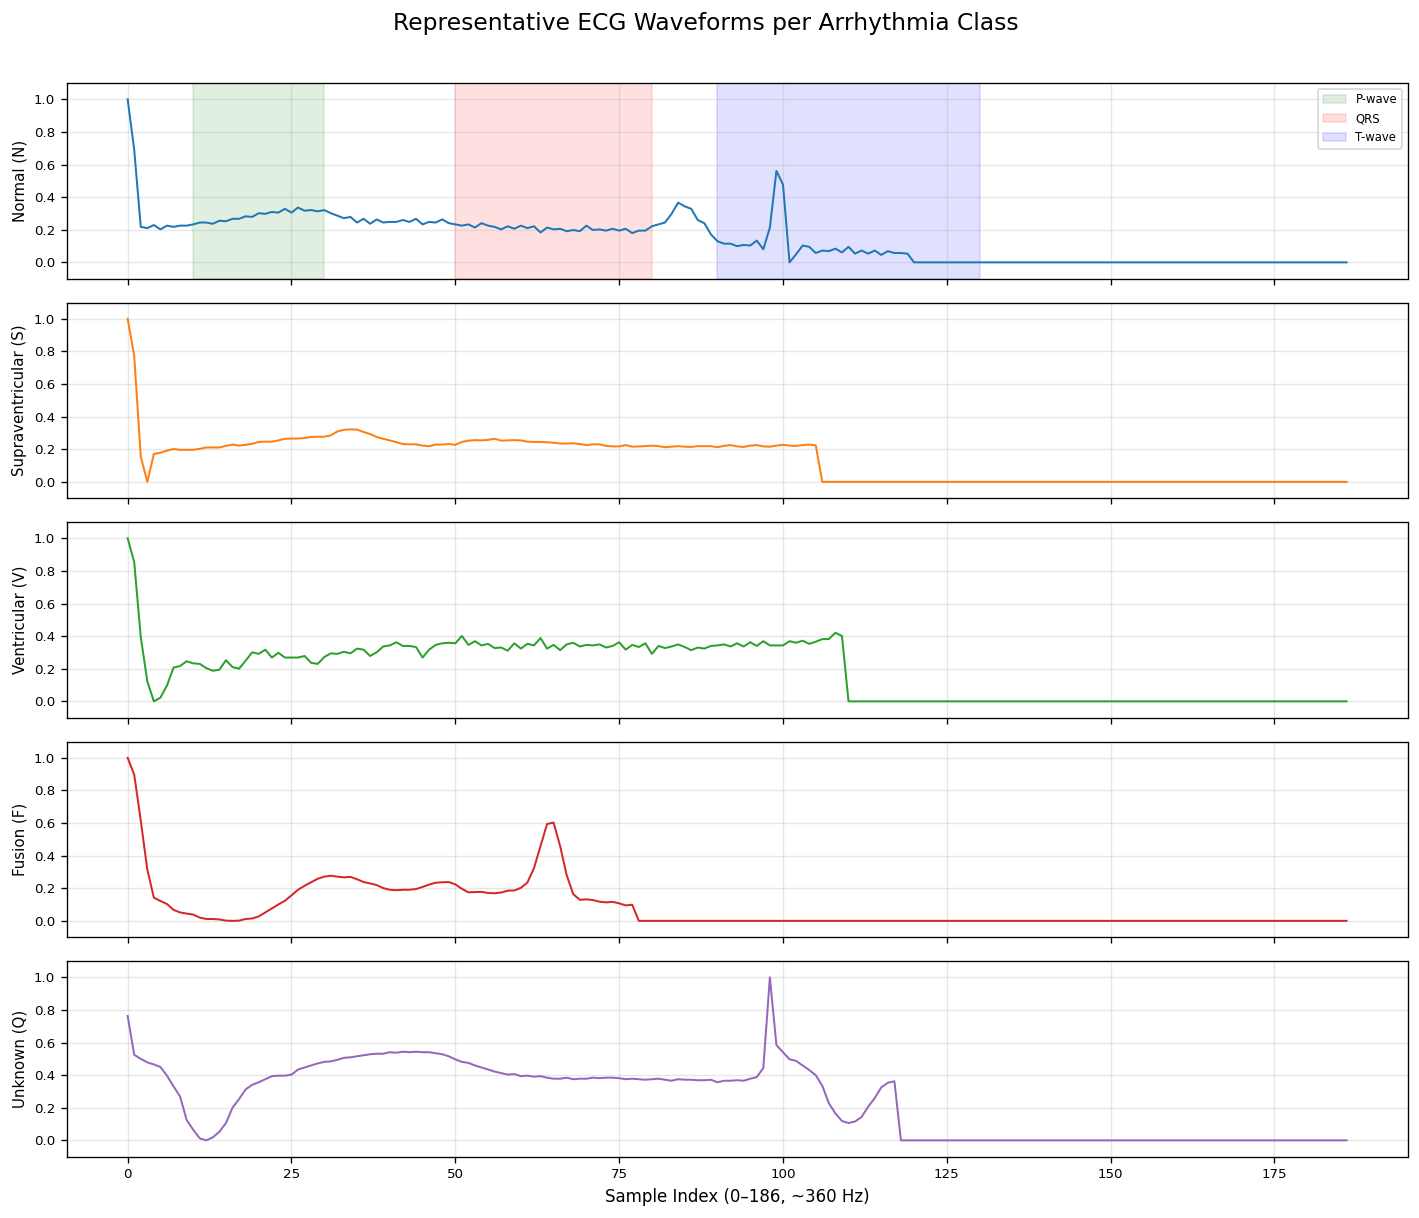

In [5]:
# Representative waveforms per class — documents morphological differences
plot_class_waveforms(X_train, y_train, save_path='results/plots/class_waveforms.png')

In [6]:
# Save canonical waveforms for Streamlit reference gallery
from pathlib import Path
reference_waveforms = {}
for class_id in range(5):
    sample = get_representative_sample(X_train, y_train, class_id)
    reference_waveforms[f'class_{class_id}'] = sample

Path('data/processed').mkdir(parents=True, exist_ok=True)
np.savez('data/processed/reference_waveforms.npz', **reference_waveforms)
print('Reference waveforms saved.')

Reference waveforms saved.
